# Proyek Analisis Data: [E-commerce]
- **Nama:** [M Fawwaz Adlan]
- **Email:** [mfawwazadlan@gmail.com]
- **ID Dicoding:** [MS011D5Y0572]

## Menentukan Pertanyaan Bisnis

- Berapa kah presentase customer yang berasal dari spain
- customer terbanyak berasal dari kota apa

## Import Semua Packages/Library yang Digunakan

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Pertama-tama kita import semua package yang di butuhkan seperti pandas,matplotip dan seaborn

## Data Wrangling

### Gathering Data

In [28]:
customer_df = pd.read_csv("olist_customers_dataset.csv")
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


setelah mengimport package yang di butuh kan.selanjutnya mengimport dataset yang di gunakan,seperti contoh nya saya yang menggunakan dataset dari E-commerce public dataset

**Insight:**
- Dari index 0-5,terlihat semua customers berasal dari SP(Spain)
- Jumlah karakter pada "customers_zip_code_prefix" memiliki jumlah karakter yang berbeda-beda

### Assessing Data

In [36]:
customer_df.info()
customer_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [33]:
print("Jumlah duplikasi: ", customer_df.duplicated().sum())

customer_df.describe()

Jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Setelah kita mengimport Dataset yang di gunakan.Langkah selanjutnya adalah mengecek apakah data tersebut memiliki masalah atau tidak

**Insight:**
- Terdapat missing value pada Kategori customer_state dan customer_city
- Dataset ini hanya memiliki empat kategori data

### Cleaning Data

In [35]:
customer_df[customer_df.customer_state.isna()]

customer_df.fillna(value="SP", inplace=True)

In [ ]:
customer_df[customer_df.customer_city.isna()]

customer_df.fillna(value="sao paulo", inplace=True)

Setelah kita mengidentifikasi masalah pada dataset,Langkah selanjutnya adalah membersihkan masalah yang terdapat pada dataset.

**Insight:**
- Karena sudah melakukan cleaning data,data ini sudah bersih dari missing value
- Data ini bersih dari,duplicate data,dan innacurate value

## Exploratory Data Analysis (EDA)

### Explore ...

In [40]:
customer_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [ ]:
customer_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [ ]:
customer_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
ibiara,1
rio espera,1
rio dos indios,1


Pada tahap ini saatnya kita mengeksplore data agar bisa menjawab pertanyaan bisnis diatas

**Insight:**
- terlihat customers terbanyak dari SP(spain)
- Terlihat customers terbanyak dari kota sao paulo

## Visualization & Explanatory Analysis

### Pertanyaan 1:

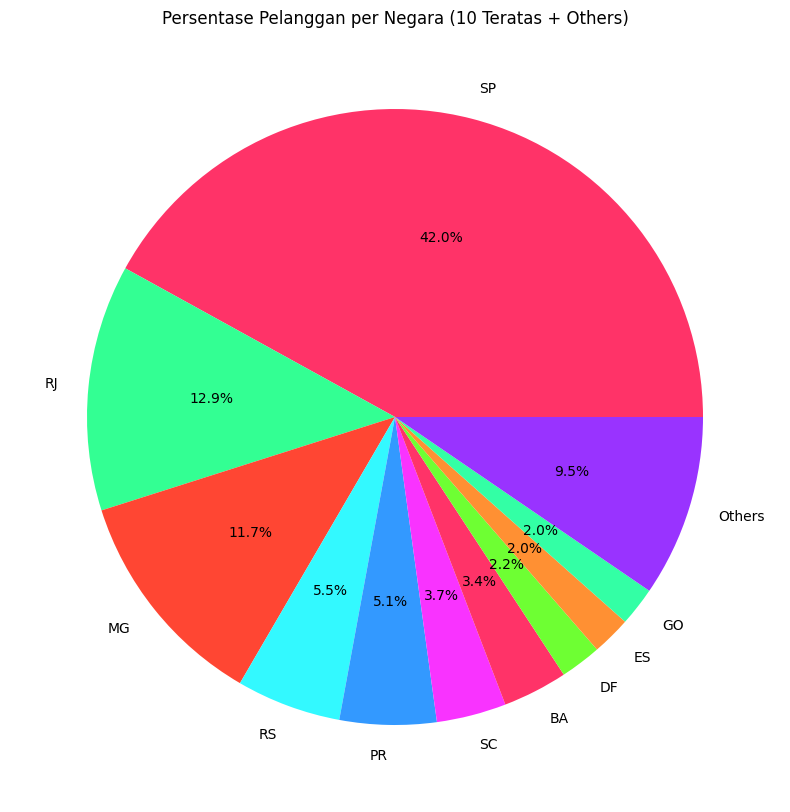

In [ ]:
jumlah_customer_per_negara = customer_df.groupby(by="customer_state")["customer_id"].count()
top_10 = customer_df.groupby(by="customer_state")["customer_id"].count().sort_values(ascending=False).head(10)
others = jumlah_customer_per_negara.sum() - top_10.sum()
data_pie = pd.concat([top_10, pd.Series({"Others": others})])
colors=("#ff3368", "#33ff93", "#ff4633", "#33f9ff", "#3399ff", "#f933ff", "#ff3368", "#6eff33", "#ff9033", "#33ffa5", "#9933ff")
plt.figure(figsize=(10, 10))
plt.pie(data_pie, labels=data_pie.index, autopct="%1.1f%%",colors=colors)
plt.title("Persentase Pelanggan per Negara (10 Teratas + Others)")
plt.show()

### Pertanyaan 2:

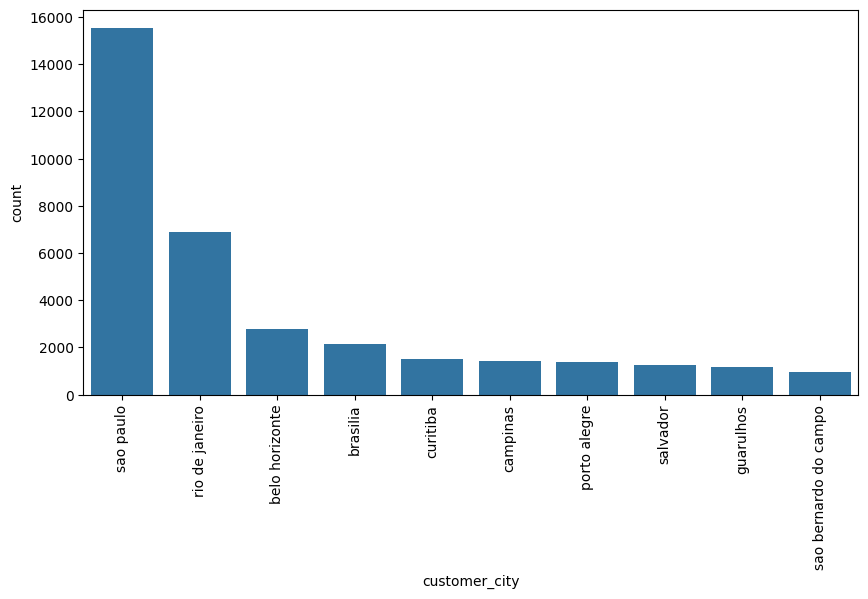

In [ ]:
plt.figure(figsize=(10, 5))
top_10_cities = customer_df["customer_city"].value_counts().head(10)
sns.countplot(data=customer_df, x="customer_city",order=top_10_cities.index)
plt.xticks(rotation=90)
plt.show()

Setelah menemukan data yang butuhkan untuk menjawab pertanyaan bisnis dari tahap exploratory data,saat nya kita melakukan visualisasi data untuk menjawab pertanyaan bisnis

**Insight:**
- Meskipun tidak termasuk dalam 10 besar, negara-negara dalam kategori "Others" mungkin memiliki potensi pertumbuhan yang signifikan.
- hanya sekitar 1500 customer yang berasal dari sao bermardo de campo

## Analisis Lanjutan (Opsional)

## Conclusion

- Kesimpulan dari pertanyaan 1.42,0% customers berasal dari spain, seperempat dari jumlah kesuluruhan customers.
- Kesimpulan dari pertanyaan 2.Sekitar 15000 customers berasal dari kota Sao paulo,hal itu menjadikan sao paulo menjadi kota dengan customers terbanyak.Diikuti oleh rio de janairo dengan sekitar 7000 customers,dan belo horizonte dengan sekitar 3000 customers.

In [42]:
customer_df.to_csv("Main_data_r.csv", index=False)